   Time_ns_pos  dist_pos  Time_ns_neg  dist_neg
0         0.00     0.354         0.00     0.333
1         0.05     0.371         0.05     0.253
2         0.10     0.425         0.10     0.301
3         0.15     0.373         0.15     0.313
4         0.20     0.385         0.20     0.268
  Zi4f: 0.283 ± 0.072
  Neg4f: 0.271 ± 0.070


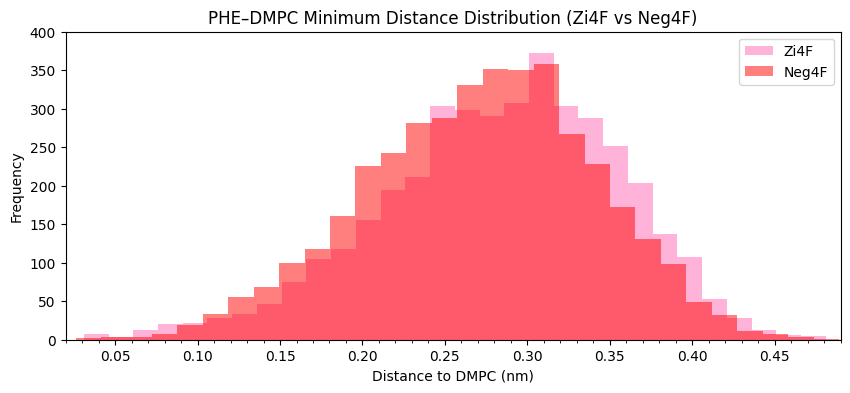

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
# === 1️⃣ Define file paths ===
pos_file = r"\analysis_03\analysis_pos\analysis_positive_200ns\Positive_PHE_residue_dmpc_distance.xvg"
neg_file = r"D:\analysis_03\analysis_neg\analysis_negative_200ns\Negative_PHE_residue_dmpc_distance.xvg"

save_hist_both = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_PHE_DMPC_Distance_Histogram.pdf"
save_hist_both2 = r"D:\OneDrive - Kent State University\mylaptop\Bicelle\PEP\analysis\analysis_03\merged02\zi4F_neg4F_PHE_DMPC_Distance_Histogram.png"





with open(pos_file) as f_pos:
    lines_pos = [line for line in f_pos if not line.startswith(('@', '#')) and line.strip()]
    Time_ns_pos = [float(line.split()[0]) for line in lines_pos]
    dist_pos = [float(line.split()[1]) for line in lines_pos]


with open(neg_file) as f_neg:
    lines_neg = [line for line in f_neg if not line.startswith(('@', '#')) and line.strip()]
    Time_ns_neg = [float(line.split()[0]) for line in lines_neg]
    dist_neg = [float(line.split()[1]) for line in lines_neg]


df = pd.DataFrame({
    "Time_ns_pos": Time_ns_pos,
    "dist_pos": dist_pos,
    "Time_ns_neg": Time_ns_neg,
    "dist_neg": dist_neg
})

# check the dataframe head 
print(df.head())
print(f"  Zi4f: {df['dist_pos'].mean():.3f} ± {df['dist_pos'].std(ddof=1):.3f}")
print(f"  Neg4f: {df['dist_neg'].mean():.3f} ± {df['dist_neg'].std(ddof=1):.3f}")





# ===  Plot Histogram Comparison ===
fig, ax =plt.subplots(figsize=(10, 4))
ax.hist(dist_pos, bins=30, color="#FF69B4", alpha=0.5, label='Zi4F')
ax.hist(dist_neg, bins=30, color="#ff0000", alpha=0.5, label='Neg4F')
ax.set_xlabel("Distance to DMPC (nm)")
ax.set_ylabel("Frequency")
ax.set_title("PHE–DMPC Minimum Distance Distribution (Zi4F vs Neg4F)")
ax.legend(loc="upper right")
ax.set_xlim(0.02, 0.49)
ax.set_ylim(0, 400)
# === Major ticks every 0.1
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
# === Optional: add grid for both major and minor ticks
# ax.grid(which='major', linestyle='--', alpha=0.6)
# ax.grid(which='minor', linestyle=':', alpha=0.3)
plt.savefig(save_hist_both, dpi=300)
plt.savefig(save_hist_both2, dpi=300)

plt.show()



